In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import shutil
import boto3
import matplotlib.pyplot as plt
import seaborn as sns

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-03-03 22:09:04.920376


#### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [4]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [5]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

# pd threshold
flt_threshold_pd = 0.6

Project: 20241112-simple-model-test
Task: 09_60_in_720
Subtask: 16_swap_in_swap_out_plots


#### Make output directory

In [6]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get swap in swap out data

#### Import scorecard predictions

In [7]:
list_cols = [
    'accountid',
    'request_datetime',
    'PD',
    'LGD',
    'ECNL',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../03_get_predictions/output/{str_filename}'
df_gen13 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'LGD': 'lgd_gen13',
    'PD': 'pd_gen13',
    'ECNL': 'ecnl_gen13',
}
df_gen13.rename(columns=dict_rename, inplace=True)
# show
df_gen13

,accountid,request_datetime,pd_gen13,lgd_gen13,ecnl_gen13
0,5782431,2024-12-20 01:09:20+00:00,0.541495,0.390043,0.466545
1,8292595,2024-11-28 06:54:03+00:00,0.282371,0.199397,0.159851
2,8300223,2024-12-03 01:52:59+00:00,0.279107,0.172898,0.137006
3,8303160,2024-11-29 23:18:44+00:00,0.723017,0.350185,0.559286
4,8306424,2024-12-17 02:28:46+00:00,0.481201,0.350185,0.478411
...,...,...,...,...,...
9995,8582527,2025-01-21 06:47:43+00:00,0.469815,0.390043,0.404788
9996,8582538,2025-01-21 06:50:53+00:00,0.468389,0.277756,0.287381
9997,8582546,2025-01-21 06:52:28+00:00,0.714612,0.350185,0.710469
9998,8582550,2025-01-21 06:53:56+00:00,0.218197,0.277756,0.133875


#### Gen 12 predictions

In [8]:
list_cols = [
    'accountid',
    'pd',
    'lgd',
    'ecnl',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../04_pricing_distribution/output/{str_filename}'
df_gen12 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'pd': 'pd_gen12',
    'lgd': 'lgd_gen12',
    'ecnl': 'ecnl_gen12',
}
df_gen12.rename(columns=dict_rename, inplace=True)
# show
df_gen12

,accountid,pd_gen12,lgd_gen12,ecnl_gen12
0,5782431,0.467144,0.607378,0.669610
1,8292595,0.337159,0.612115,0.487056
2,8300223,0.092892,0.675231,0.148027
3,8303160,0.490566,0.665277,0.770214
4,8306424,0.144040,0.652269,0.221729
...,...,...,...,...
9995,8582527,0.553526,0.653014,0.853046
9996,8582538,0.355347,0.707807,0.593580
9997,8582546,0.527200,0.651498,0.810588
9998,8582550,0.128649,0.601011,0.182473


#### Join

In [9]:
# join
df = pd.merge(
    left=df_gen12,
    right=df_gen13,
    on='accountid',
    how='inner',
)
# save memory
del df_gen12
del df_gen13
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_gen13,lgd_gen13,ecnl_gen13
0,5782431,0.467144,0.607378,0.669610,2024-12-20 01:09:20+00:00,0.541495,0.390043,0.466545
1,8292595,0.337159,0.612115,0.487056,2024-11-28 06:54:03+00:00,0.282371,0.199397,0.159851
2,8300223,0.092892,0.675231,0.148027,2024-12-03 01:52:59+00:00,0.279107,0.172898,0.137006
3,8303160,0.490566,0.665277,0.770214,2024-11-29 23:18:44+00:00,0.723017,0.350185,0.559286
4,8306424,0.144040,0.652269,0.221729,2024-12-17 02:28:46+00:00,0.481201,0.350185,0.478411
...,...,...,...,...,...,...,...,...
9995,8582527,0.553526,0.653014,0.853046,2025-01-21 06:47:43+00:00,0.469815,0.390043,0.404788
9996,8582538,0.355347,0.707807,0.593580,2025-01-21 06:50:53+00:00,0.468389,0.277756,0.287381
9997,8582546,0.527200,0.651498,0.810588,2025-01-21 06:52:28+00:00,0.714612,0.350185,0.710469
9998,8582550,0.128649,0.601011,0.182473,2025-01-21 06:53:56+00:00,0.218197,0.277756,0.133875


#### Get raw data

In [10]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/02_parse_payloads/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
df_tmp['amtfinanced__app']= df_tmp['amtfinanced__app'].replace(0, np.nan)
df_tmp['bookvalue__app'] = df_tmp['bookvalue__app'].replace(0, np.nan)
df_tmp['ENG-loan_to_value'] = df_tmp['amtfinanced__app'] / df_tmp['bookvalue__app']
# df_tmp['ENG-loan_to_value'] = df_tmp['ENG-loan_to_value'].replace(0, np.nan)
# df_tmp['ENG-loan_to_value'] = df_tmp['ENG-loan_to_value'].fillna(1.27)

# bk tag
df_tmp['intopenbktype__app'] = df_tmp['intopenbktype__app'].apply(lambda x: 0 if pd.isna(x) else 1)

# franchise tag -- referrals make 0
df_tmp['strdealershiptrackertype__app'] = df_tmp['strdealershiptrackertype__app'].apply(lambda x: 0 if x=='Independent' else 1)

# group
df_tmp = df_tmp.groupby(by='accountid', as_index=False).agg({
    'intopenbktype__app': 'first',
    'ENG-loan_to_value': 'first',
    'strdealershiptrackertype__app': 'first',
    'fltgrossmonthly__income_sum': 'sum',
    'miles_odometer__app': 'first',
})
# show
df_tmp

,accountid,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app
0,5782431,0,NaN,1,4502.38,77837
1,8292595,0,0.501786,1,7056.00,57677
2,8300223,1,0.994140,1,10860.53,42128
3,8303160,0,1.193988,0,3501.31,74484
4,8306424,0,1.212453,0,11605.52,59650
...,...,...,...,...,...,...
9995,8582527,0,1.318922,1,3587.00,70054
9996,8582538,0,0.998997,0,3890.00,53654
9997,8582546,0,1.250000,0,4100.00,41221
9998,8582550,0,0.967072,1,11000.00,154978


#### Join

In [11]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='accountid',
    how='left',
)

# get intnrows
int_nrows = df.shape[0]

# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_gen13,lgd_gen13,ecnl_gen13,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app
0,5782431,0.467144,0.607378,0.669610,2024-12-20 01:09:20+00:00,0.541495,0.390043,0.466545,0,NaN,1,4502.38,77837
1,8292595,0.337159,0.612115,0.487056,2024-11-28 06:54:03+00:00,0.282371,0.199397,0.159851,0,0.501786,1,7056.00,57677
2,8300223,0.092892,0.675231,0.148027,2024-12-03 01:52:59+00:00,0.279107,0.172898,0.137006,1,0.994140,1,10860.53,42128
3,8303160,0.490566,0.665277,0.770214,2024-11-29 23:18:44+00:00,0.723017,0.350185,0.559286,0,1.193988,0,3501.31,74484
4,8306424,0.144040,0.652269,0.221729,2024-12-17 02:28:46+00:00,0.481201,0.350185,0.478411,0,1.212453,0,11605.52,59650
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8582527,0.553526,0.653014,0.853046,2025-01-21 06:47:43+00:00,0.469815,0.390043,0.404788,0,1.318922,1,3587.00,70054
9996,8582538,0.355347,0.707807,0.593580,2025-01-21 06:50:53+00:00,0.468389,0.277756,0.287381,0,0.998997,0,3890.00,53654
9997,8582546,0.527200,0.651498,0.810588,2025-01-21 06:52:28+00:00,0.714612,0.350185,0.710469,0,1.250000,0,4100.00,41221
9998,8582550,0.128649,0.601011,0.182473,2025-01-21 06:53:56+00:00,0.218197,0.277756,0.133875,0,0.967072,1,11000.00,154978


#### Create tier

In [12]:
# gen 12
df['tier_gen12'] = df['ecnl_gen12'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# gen 13
df['tier_gen13'] = df['ecnl_gen13'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_gen13,lgd_gen13,ecnl_gen13,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app,tier_gen12,tier_gen13
0,5782431,0.467144,0.607378,0.669610,2024-12-20 01:09:20+00:00,0.541495,0.390043,0.466545,0,NaN,1,4502.38,77837,Decline,Decline
1,8292595,0.337159,0.612115,0.487056,2024-11-28 06:54:03+00:00,0.282371,0.199397,0.159851,0,0.501786,1,7056.00,57677,Decline,B
2,8300223,0.092892,0.675231,0.148027,2024-12-03 01:52:59+00:00,0.279107,0.172898,0.137006,1,0.994140,1,10860.53,42128,B,B
3,8303160,0.490566,0.665277,0.770214,2024-11-29 23:18:44+00:00,0.723017,0.350185,0.559286,0,1.193988,0,3501.31,74484,Decline,Decline
4,8306424,0.144040,0.652269,0.221729,2024-12-17 02:28:46+00:00,0.481201,0.350185,0.478411,0,1.212453,0,11605.52,59650,B,Decline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8582527,0.553526,0.653014,0.853046,2025-01-21 06:47:43+00:00,0.469815,0.390043,0.404788,0,1.318922,1,3587.00,70054,Decline,Decline
9996,8582538,0.355347,0.707807,0.593580,2025-01-21 06:50:53+00:00,0.468389,0.277756,0.287381,0,0.998997,0,3890.00,53654,Decline,C
9997,8582546,0.527200,0.651498,0.810588,2025-01-21 06:52:28+00:00,0.714612,0.350185,0.710469,0,1.250000,0,4100.00,41221,Decline,Decline
9998,8582550,0.128649,0.601011,0.182473,2025-01-21 06:53:56+00:00,0.218197,0.277756,0.133875,0,0.967072,1,11000.00,154978,B,B


#### LTV

In [13]:
# cap all ltv to 1.27
df['ENG-loan_to_value'] = df['ENG-loan_to_value'].apply(lambda x: min(x, 1.27))

# gen 12
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'ENG-loan_to_value': 'mean',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'ENG-loan_to_value':'gen12_mean_LTV'}, inplace=True)

# gen 13
df_tmp2 = df.groupby(by=['tier_gen13'], as_index=False).agg({
    'ENG-loan_to_value': 'mean',
})

df_tmp2.rename(columns={'tier_gen13':'Tier', 'ENG-loan_to_value':'gen13_mean_LTV'},  inplace=True)

In [14]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values

# show
df_tmp

,Tier,gen12_mean_LTV,gen13_mean_LTV
0,A1,1.054242,0.645850
1,A,1.042014,0.923193
2,B,1.042400,1.028719
3,C,1.024553,1.078851
4,D,1.042631,1.096430
5,Decline,1.129628,1.145600


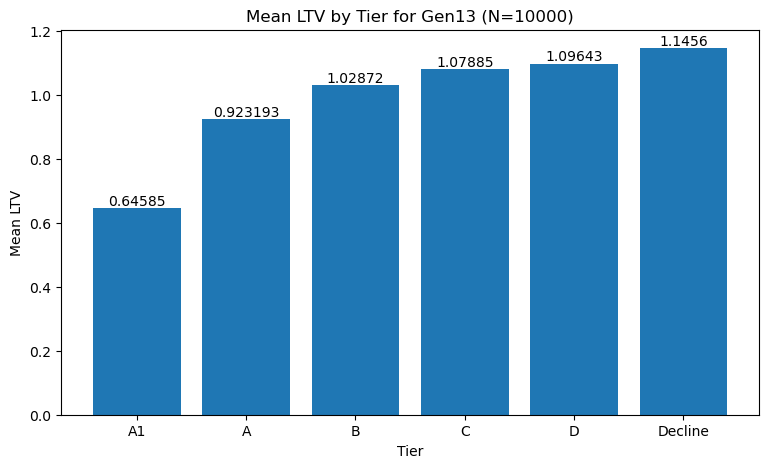

In [15]:
# # melt
# df_melted = df_tmp.melt(id_vars='Tier', var_name='LTV', value_name='Average LTV')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean LTV by Tier for Gen13 (N={int_nrows})')
ax.set_ylabel('Mean LTV')
ax.set_xlabel('Tier')
bars = ax.bar(df_tmp['Tier'], df_tmp['gen13_mean_LTV'])
ax.bar_label(bars)

# save
str_filename = 'plt_stacked_ltv.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### Income

In [16]:
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'fltgrossmonthly__income_sum': 'median',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'fltgrossmonthly__income_sum':'gen12_median_income'}, inplace=True)

df_tmp2 = df.groupby(by=['tier_gen13'], as_index=False).agg({
    'fltgrossmonthly__income_sum': 'median',
})

df_tmp2.rename(columns={'tier_gen13':'Tier', 'fltgrossmonthly__income_sum':'gen13_median_income'},  inplace=True)

In [17]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values

# show
df_tmp

,Tier,gen12_median_income,gen13_median_income
0,A1,7610.300,5500.0
1,A,6444.935,6000.0
2,B,5500.000,5500.0
3,C,5000.000,5300.0
4,D,5000.000,5000.0
5,Decline,4800.000,4837.0


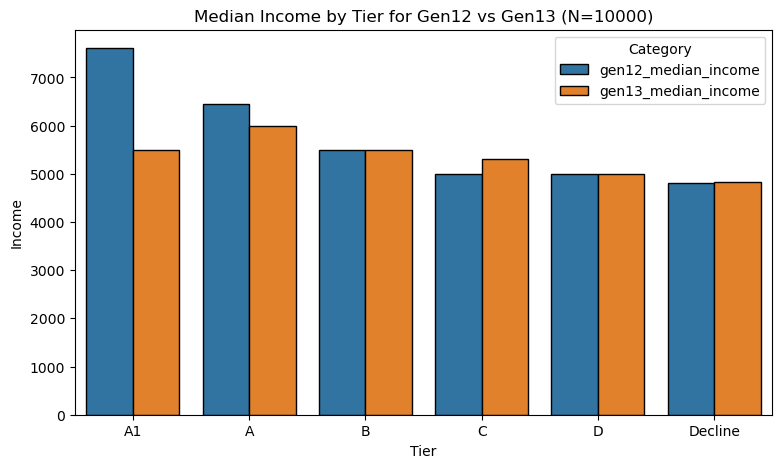

In [18]:
# melt
df_melted = df_tmp.melt(id_vars='Tier', var_name='Median Income', value_name='Income')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Median Income by Tier for Gen12 vs Gen13 (N={int_nrows})')
sns.barplot(x='Tier', y='Income', hue='Median Income', data=df_melted, estimator=sum, edgecolor='black')
plt.legend(title='Category', loc='upper right')

# save
str_filename = 'plt_stacked_income.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### BK frequency

In [19]:
# filter
df_filtered = df[df['tier_gen12'] != 'Decline']
df_filtered2 = df[df['tier_gen13'] != 'Decline']

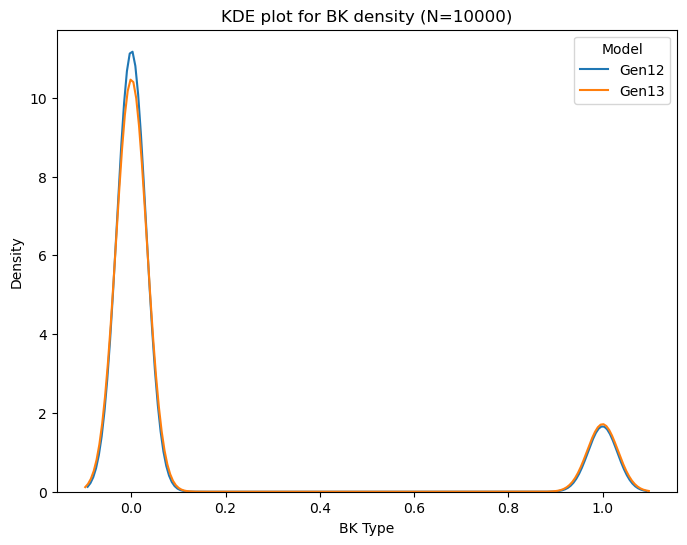

In [20]:
# kde plot
plt.figure(figsize=(8, 6))
sns.kdeplot(df_filtered['intopenbktype__app'], bw_adjust=0.5, fill=False, label='Gen12')
sns.kdeplot(df_filtered2['intopenbktype__app'], bw_adjust=0.5, fill=False, label='Gen13')

# labels
plt.xlabel('BK Type')
plt.ylabel('Density')
plt.title(f'KDE plot for BK density (N={int_nrows})')
plt.legend(title='Model', loc='upper right')

# show
plt.show()

#### BK tag

In [21]:
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'intopenbktype__app': 'mean',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'intopenbktype__app':'gen12_mean_bk_prop'}, inplace=True)

df_tmp2 = df.groupby(by=['tier_gen13'], as_index=False).agg({
    'intopenbktype__app': 'mean',
})

df_tmp2.rename(columns={'tier_gen13':'Tier', 'intopenbktype__app':'gen13_mean_bk_prop'},  inplace=True)

In [22]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values

# show
df_tmp

,Tier,gen12_mean_bk_prop,gen13_mean_bk_prop
0,A1,0.340708,0.219814
1,A,0.273707,0.224824
2,B,0.133827,0.156863
3,C,0.065060,0.090737
4,D,0.061934,0.070524
5,Decline,0.032912,0.030598


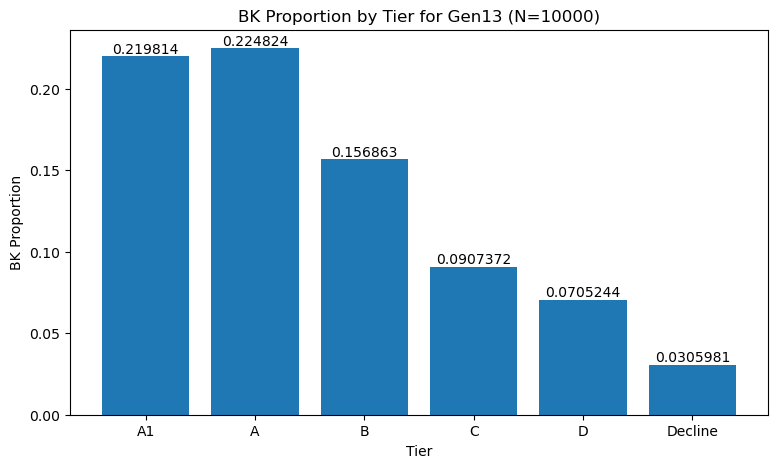

In [23]:
# # melt
# df_melted = df_tmp.melt(id_vars='Tier', var_name='BK prop', value_name='BK Proportion')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'BK Proportion by Tier for Gen13 (N={int_nrows})')
ax.set_ylabel('BK Proportion')
ax.set_xlabel('Tier')
bars = ax.bar(df_tmp['Tier'], df_tmp['gen13_mean_bk_prop'])
ax.bar_label(bars)

# save
str_filename = 'plt_stacked_bk.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### Miles Odo

In [24]:
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'miles_odometer__app': 'mean',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'miles_odometer__app':'gen12_mean_miles_odometer'}, inplace=True)
# round to hundredth
df_tmp["gen12_mean_miles_odometer"] = df_tmp["gen12_mean_miles_odometer"].round(2)

df_tmp2 = df.groupby(by=['tier_gen13'], as_index=False).agg({
    'miles_odometer__app': 'mean',
})

df_tmp2.rename(columns={'tier_gen13':'Tier', 'miles_odometer__app':'gen13_mean_miles_odometer'},  inplace=True)
# round to hundredth
df_tmp2["gen13_mean_miles_odometer"] = df_tmp2["gen13_mean_miles_odometer"].round(2)

In [25]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values

# show
df_tmp

,Tier,gen12_mean_miles_odometer,gen13_mean_miles_odometer
0,A1,43401.71,31031.32
1,A,42296.18,37670.32
2,B,48775.18,45186.93
3,C,50490.19,52309.50
4,D,53780.14,50524.88
5,Decline,55755.93,57695.12


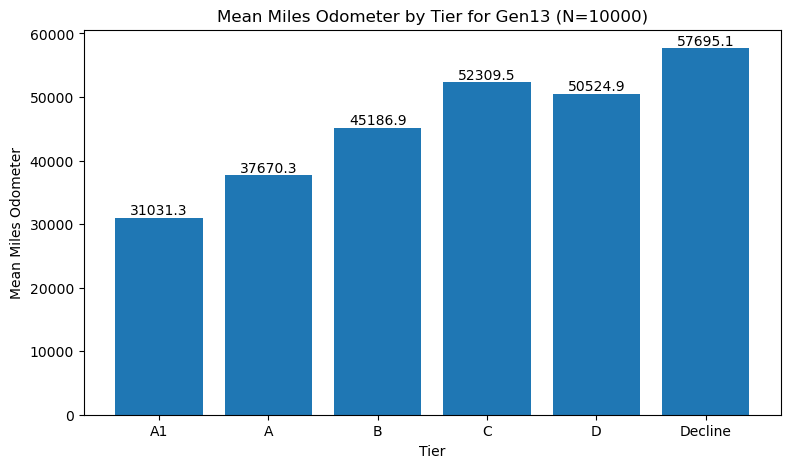

In [26]:
# melt
# df_melted = df_tmp.melt(id_vars='Tier', var_name='Mean Miles Odometer', value_name='Miles')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean Miles Odometer by Tier for Gen13 (N={int_nrows})')
ax.set_ylabel('Mean Miles Odometer')
ax.set_xlabel('Tier')
bars = ax.bar(df_tmp['Tier'], df_tmp['gen13_mean_miles_odometer'])
ax.bar_label(bars)

# save
str_filename = 'plt_stacked_miles_odometer.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### Franchise tag

In [27]:
df_tmp = df.groupby(by=['tier_gen12'], as_index=False).agg({
    'strdealershiptrackertype__app': 'mean',
})

df_tmp.rename(columns={'tier_gen12':'Tier', 'strdealershiptrackertype__app':'gen12_prop_franchise'}, inplace=True)

df_tmp2 = df.groupby(by=['tier_gen13'], as_index=False).agg({
    'strdealershiptrackertype__app': 'mean',
})

df_tmp2.rename(columns={'tier_gen13':'Tier', 'strdealershiptrackertype__app':'gen13_prop_franchise'},  inplace=True)

In [28]:
# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)

df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values

# show
df_tmp

,Tier,gen12_prop_franchise,gen13_prop_franchise
0,A1,0.796460,0.764706
1,A,0.765086,0.803279
2,B,0.683951,0.709592
3,C,0.659438,0.655009
4,D,0.613293,0.647378
5,Decline,0.566382,0.558588


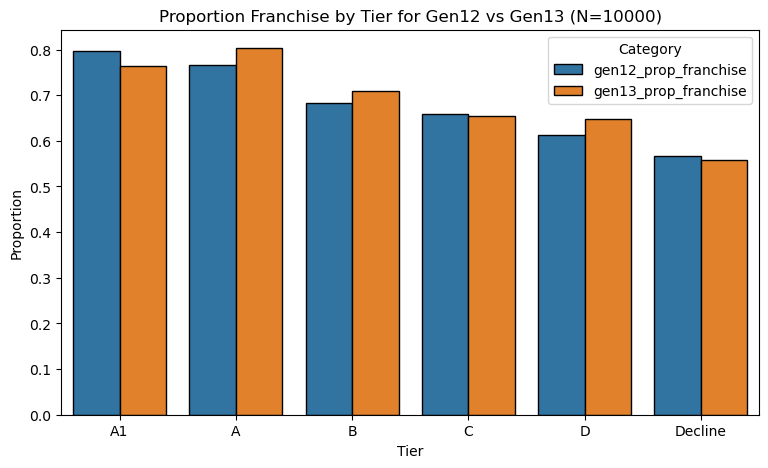

In [29]:
# melt
df_melted = df_tmp.melt(id_vars='Tier', var_name='Franchise Prop', value_name='Proportion')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Proportion Franchise by Tier for Gen12 vs Gen13 (N={int_nrows})')
sns.barplot(x='Tier', y='Proportion', hue='Franchise Prop', data=df_melted, estimator=sum, edgecolor='black')
plt.legend(title='Category', loc='upper right')

# save
str_filename = 'plt_stacked_franchise_prop.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

#### Prop tier each model

In [30]:
# gen 12 tier
df_tmp = df.groupby("tier_gen12").count().reset_index()
df_tmp = df_tmp[['tier_gen12', 'accountid']]
df_tmp.iloc[[0, 1]] = df_tmp.iloc[[1, 0]].values
df_tmp = df_tmp.rename(columns={'tier_gen12':'Tier', 'accountid':'tier_gen12'})
df_tmp["prop_gen12"] = df_tmp["tier_gen12"] / df_tmp["tier_gen12"].sum()

# gen 13 ter
df_tmp2 = df.groupby("tier_gen13").count().reset_index()
df_tmp2 = df_tmp2[['tier_gen13', 'accountid']]
df_tmp2.iloc[[0, 1]] = df_tmp2.iloc[[1, 0]].values
df_tmp2 = df_tmp2.rename(columns={'tier_gen13':'Tier', 'accountid':'tier_gen13'})
df_tmp2["prop_gen13"] = df_tmp2["tier_gen13"] / df_tmp2["tier_gen13"].sum()
df_tmp2

# merge
df_tmp = pd.merge(
    left=df_tmp,
    right=df_tmp2,
    on='Tier',
    how='left',
)
df_tmp

# get cols we need
list_cols = ['Tier', 'prop_gen12', 'prop_gen13']
df_tmp = df_tmp[list_cols]

# rearrange cols
order_ = ["A1", "A", "B", "C", "D", "Decline"]

df_tmp["Tier"] = pd.Categorical(df_tmp["Tier"], categories=order_, ordered=True)
df_tmp = df_tmp.sort_values("Tier").reset_index(drop=True)

df_tmp

,Tier,prop_gen12,prop_gen13
0,A1,0.0226,0.0323
1,A,0.0464,0.0427
2,B,0.2025,0.1887
3,C,0.1245,0.1058
4,D,0.0662,0.0553
5,Decline,0.5378,0.5752


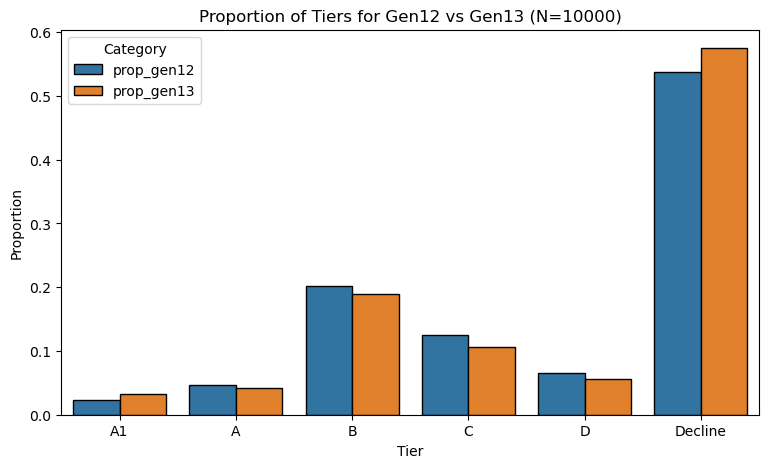

In [31]:
# melt
df_melted = df_tmp.melt(id_vars='Tier', var_name='Prop Tier', value_name='Proportion')

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Proportion of Tiers for Gen12 vs Gen13 (N={int_nrows})')
sns.barplot(x='Tier', y='Proportion', hue='Prop Tier', data=df_melted, estimator=sum, edgecolor='black')
plt.legend(title='Category', loc='upper left')

# save
str_filename = 'plt_stacked_tier.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')